## Name : Owen Nda Diche | Student ID : 24152506

# What Does an Autoencoder Remember?

## Exploring Latent Dimension and Reconstruction Quality with Fashion-MNIST

### Tutorial objective
This notebook demonstrates how the size of the latent dimension in an autoencoder affects image reconstruction quality.

An autoencoder is a neural network trained to reproduce its input. It consists of:
- an **encoder**, which compresses the input into a lower-dimensional representation
- a **decoder**, which reconstructs the original input from that compressed representation

The compressed representation is often called the **latent space** or **bottleneck**.

In this tutorial, we will:
1. Load the Fashion-MNIST dataset
2. Build a fully connected autoencoder
3. Train the model with different latent dimensions
4. Compare reconstruction losses
5. Visualise reconstructed images
6. Interpret what the model remembers and what it loses as compression increases

### Why this matters
The latent dimension controls how much information the autoencoder can store. If it is too small, important visual details may be lost. If it is larger, reconstruction quality may improve, but compression becomes weaker.

This makes latent dimension an important design choice when using autoencoders for:
- dimensionality reduction
- feature learning
- compression
- anomaly detection
- denoising

GitHub repository: https://github.com/owendiche-sys/Autoencoder-Latent-Dimension-Tutorial

## Install and import packages

The code below imports the libraries needed for:
- data loading
- model building
- training
- plotting results

This notebook uses **PyTorch** for the autoencoder implementation.

In [14]:
# If you are using Google Colab and PyTorch is not already installed, uncomment:
# !pip install torch torchvision matplotlib scikit-learn

import random
import numpy as np
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE
from sklearn.metrics import mean_squared_error

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

print("PyTorch version:", torch.__version__)

PyTorch version: 2.10.0+cu128


## Set a random seed and choose a device

To make results more reproducible, we set random seeds.
We also check whether a GPU is available. If not, the notebook will run on CPU.

In [15]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## Load the Fashion-MNIST dataset

Fashion-MNIST contains grayscale images of clothing items such as shirts, shoes, bags and coats.

Each image:
- has shape **28 × 28**
- is grayscale
- belongs to one of 10 classes

For this tutorial, the class labels are useful mainly for visualisation. The autoencoder itself is trained **without using labels**, because its task is to reconstruct the input image.

In [16]:
transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

class_names = train_dataset.classes
print("Classes:", class_names)
print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
Training samples: 60000
Test samples: 10000


## Create dataloaders

To keep the notebook practical and fast to run, we will use a subset of the full training data.
This is usually enough for a tutorial while keeping training time reasonable.

You can increase the subset size later if you want stronger results.

In [17]:
# Use a subset for faster training in tutorial settings
train_subset_size = 12000
test_subset_size = 2000

train_indices = list(range(train_subset_size))
test_indices = list(range(test_subset_size))

train_subset = Subset(train_dataset, train_indices)
test_subset = Subset(test_dataset, test_indices)

batch_size = 128

train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)

print("Train subset size:", len(train_subset))
print("Test subset size:", len(test_subset))

Train subset size: 12000
Test subset size: 2000


## Visualise some sample images

Before training the model, it is useful to inspect the dataset.
This also helps us later when comparing original and reconstructed images.

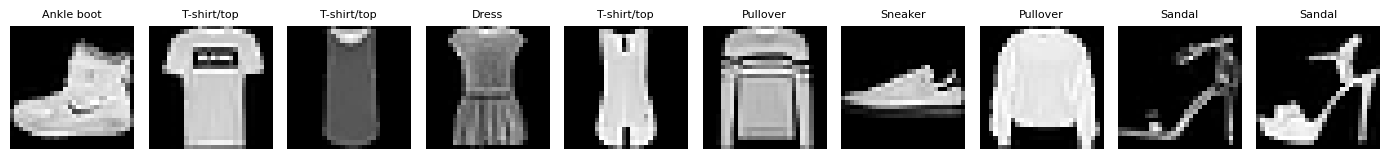

In [18]:
def show_sample_images(dataset, class_names, n=10):
    fig, axes = plt.subplots(1, n, figsize=(14, 2))
    for i in range(n):
        image, label = dataset[i]
        axes[i].imshow(image.squeeze(), cmap="gray")
        axes[i].set_title(class_names[label], fontsize=8)
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()

show_sample_images(train_dataset, class_names, n=10)

## Define the autoencoder

We will use a simple **fully connected autoencoder**.

### Architecture
- The input image is flattened from **28 × 28** into a vector of length **784**
- The encoder reduces this vector to a smaller latent representation
- The decoder reconstructs the image from that latent vector

The only thing we will vary across experiments is the **latent dimension**.

This allows us to isolate the effect of bottleneck size on reconstruction quality.

In [19]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 28 * 28),
            nn.Sigmoid()  # output pixel values between 0 and 1
        )

    def forward(self, x):
        z = self.encoder(x)
        reconstruction = self.decoder(z)
        reconstruction = reconstruction.view(-1, 1, 28, 28)
        return reconstruction

## Define training and evaluation functions

The autoencoder is trained by comparing the reconstructed image to the original image.

We will use **Mean Squared Error (MSE)** as the reconstruction loss.

A lower loss means that the reconstructed image is closer to the original.

In [20]:
def train_autoencoder(model, train_loader, test_loader, epochs=10, lr=1e-3):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    test_losses = []

    model.to(device)

    for epoch in range(epochs):
        model.train()
        running_train_loss = 0.0

        for images, _ in train_loader:
            images = images.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, images)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * images.size(0)

        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        model.eval()
        running_test_loss = 0.0

        with torch.no_grad():
            for images, _ in test_loader:
                images = images.to(device)
                outputs = model(images)
                loss = criterion(outputs, images)
                running_test_loss += loss.item() * images.size(0)

        epoch_test_loss = running_test_loss / len(test_loader.dataset)
        test_losses.append(epoch_test_loss)

        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train Loss: {epoch_train_loss:.6f} | "
            f"Test Loss: {epoch_test_loss:.6f}"
        )

    return train_losses, test_losses

## Train multiple autoencoders with different latent dimensions

We now train the same model several times, changing only the size of the bottleneck.

This will let us compare:
- how reconstruction loss changes
- how reconstructed images change
- whether a very small latent space loses important information

The chosen latent dimensions are:
- 2
- 8
- 16
- 32
- 64

These values move from very strong compression to more relaxed compression.

In [21]:
latent_dims = [2, 8, 16, 32, 64]
epochs = 15

results = {}

for latent_dim in latent_dims:
    print(f"\nTraining autoencoder with latent_dim = {latent_dim}")
    model = Autoencoder(latent_dim=latent_dim)
    train_losses, test_losses = train_autoencoder(
        model, train_loader, test_loader, epochs=epochs, lr=1e-3
    )

    results[latent_dim] = {
        "model": model,
        "train_losses": train_losses,
        "test_losses": test_losses,
        "final_test_loss": test_losses[-1]
    }


Training autoencoder with latent_dim = 2
Epoch [1/15] | Train Loss: 0.075864 | Test Loss: 0.044617
Epoch [2/15] | Train Loss: 0.041887 | Test Loss: 0.038216
Epoch [3/15] | Train Loss: 0.037311 | Test Loss: 0.035189
Epoch [4/15] | Train Loss: 0.035262 | Test Loss: 0.034070
Epoch [5/15] | Train Loss: 0.034214 | Test Loss: 0.033613
Epoch [6/15] | Train Loss: 0.033576 | Test Loss: 0.032957
Epoch [7/15] | Train Loss: 0.032918 | Test Loss: 0.032346
Epoch [8/15] | Train Loss: 0.032469 | Test Loss: 0.031927
Epoch [9/15] | Train Loss: 0.032008 | Test Loss: 0.031894
Epoch [10/15] | Train Loss: 0.031650 | Test Loss: 0.031068
Epoch [11/15] | Train Loss: 0.031242 | Test Loss: 0.030834
Epoch [12/15] | Train Loss: 0.030794 | Test Loss: 0.030826
Epoch [13/15] | Train Loss: 0.030542 | Test Loss: 0.030183
Epoch [14/15] | Train Loss: 0.030237 | Test Loss: 0.030551
Epoch [15/15] | Train Loss: 0.029946 | Test Loss: 0.029938

Training autoencoder with latent_dim = 8
Epoch [1/15] | Train Loss: 0.076888 | Te

## Compare reconstruction loss across latent dimensions

A smaller reconstruction loss indicates that the model is reconstructing images more accurately.

This helps us quantify the effect of latent dimension, beyond just visually inspecting images.

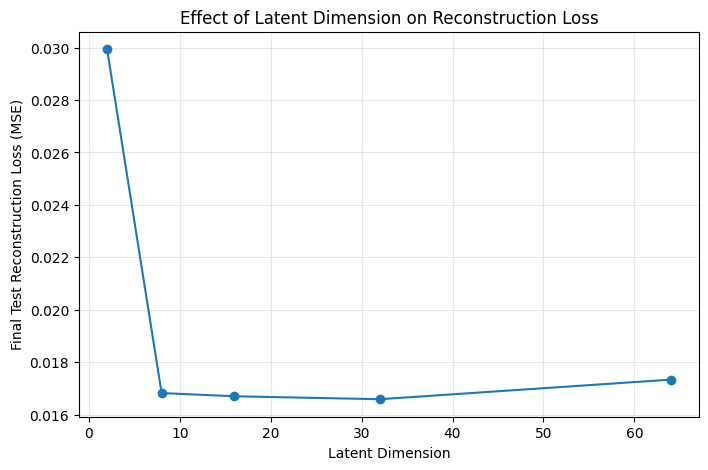

Latent dimension  2: Final test loss = 0.029938
Latent dimension  8: Final test loss = 0.016821
Latent dimension 16: Final test loss = 0.016698
Latent dimension 32: Final test loss = 0.016586
Latent dimension 64: Final test loss = 0.017333


In [22]:
final_losses = [results[dim]["final_test_loss"] for dim in latent_dims]

plt.figure(figsize=(8, 5))
plt.plot(latent_dims, final_losses, marker="o")
plt.xlabel("Latent Dimension")
plt.ylabel("Final Test Reconstruction Loss (MSE)")
plt.title("Effect of Latent Dimension on Reconstruction Loss")
plt.grid(True, alpha=0.3)
plt.show()

for dim, loss in zip(latent_dims, final_losses):
    print(f"Latent dimension {dim:>2}: Final test loss = {loss:.6f}")

## Plot training and test loss curves

Loss curves help us check whether learning is stable.

They also show whether larger latent dimensions learn faster or achieve lower error over time.

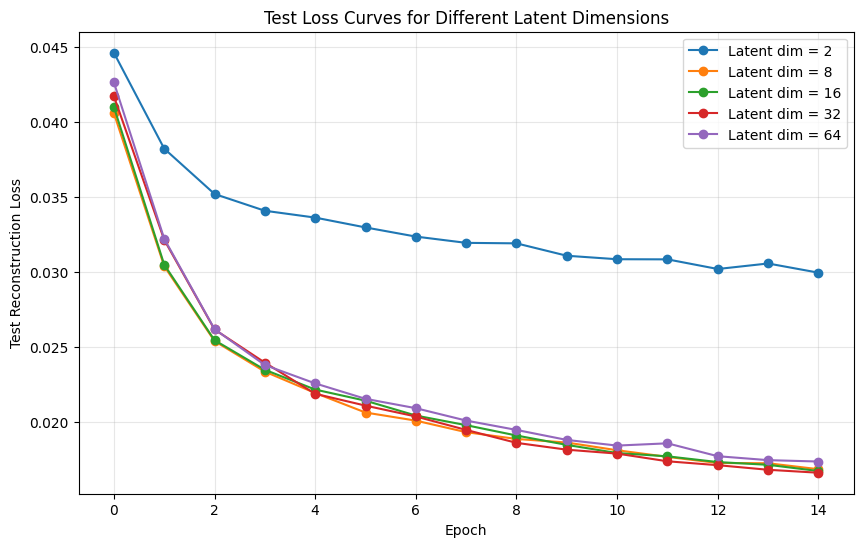

In [23]:
plt.figure(figsize=(10, 6))

for latent_dim in latent_dims:
    plt.plot(
        results[latent_dim]["test_losses"],
        marker="o",
        label=f"Latent dim = {latent_dim}"
    )

plt.xlabel("Epoch")
plt.ylabel("Test Reconstruction Loss")
plt.title("Test Loss Curves for Different Latent Dimensions")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Visualise original and reconstructed images

Numerical loss is useful, but autoencoders are especially informative when we inspect reconstructed images directly.

We will show:
- the original images
- the reconstructions produced by each autoencoder

This makes it easier to see which visual details are preserved and which are lost.

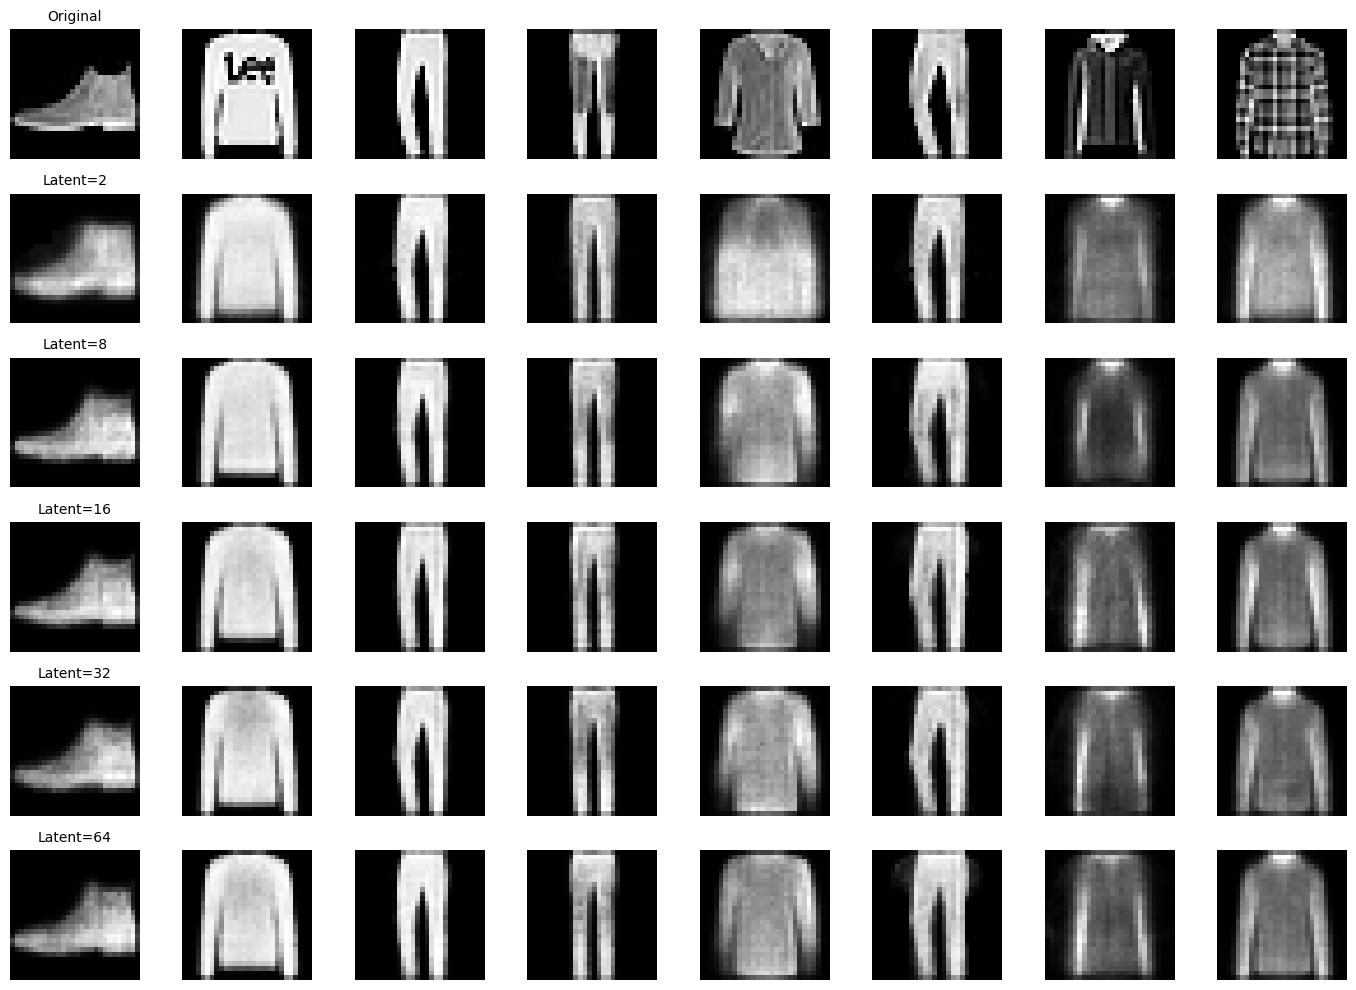

In [24]:
def get_reconstructions(model, dataloader, num_images=8):
    model.eval()
    images_batch, _ = next(iter(dataloader))
    images_batch = images_batch.to(device)

    with torch.no_grad():
        reconstructions = model(images_batch)

    return images_batch[:num_images].cpu(), reconstructions[:num_images].cpu()

num_images = 8
originals, _ = get_reconstructions(results[latent_dims[0]]["model"], test_loader, num_images=num_images)

fig, axes = plt.subplots(len(latent_dims) + 1, num_images, figsize=(14, 10))

# First row: originals
for i in range(num_images):
    axes[0, i].imshow(originals[i].squeeze(), cmap="gray")
    axes[0, i].axis("off")
    if i == 0:
        axes[0, i].set_title("Original", fontsize=10)

# Remaining rows: reconstructions for each latent dimension
for row, latent_dim in enumerate(latent_dims, start=1):
    model = results[latent_dim]["model"]
    originals_batch, recon_batch = get_reconstructions(model, test_loader, num_images=num_images)

    for i in range(num_images):
        axes[row, i].imshow(recon_batch[i].squeeze(), cmap="gray")
        axes[row, i].axis("off")
        if i == 0:
            axes[row, i].set_title(f"Latent={latent_dim}", fontsize=10)

plt.tight_layout()
plt.show()

## Interpret the reconstruction results

At this stage, we expect to see a pattern such as:

- **Latent dimension = 2**: strong compression, but blurry or oversimplified reconstructions
- **Latent dimension = 8 or 16**: better balance between compression and image quality
- **Latent dimension = 32 or 64**: clearer reconstructions, but less aggressive compression

This reflects the central trade-off in autoencoders:
a smaller bottleneck forces the model to compress more strongly, but it may lose important details.

##  Visualise the latent space for the 2-dimensional model

When the latent dimension is exactly 2, each image is represented by just two numbers.

This allows us to visualise the latent space directly on a 2D scatter plot.

Although the autoencoder is not trained for classification, similar clothing items may still form loose groups in the latent space if the learned representation captures useful structure.

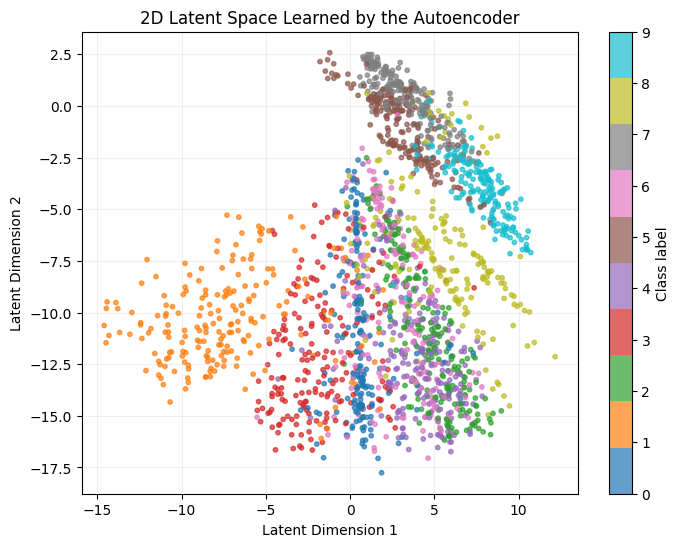

In [25]:
def extract_latent_vectors(model, dataloader):
    model.eval()
    latent_vectors = []
    labels_list = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            z = model.encoder(images)
            latent_vectors.append(z.cpu().numpy())
            labels_list.append(labels.numpy())

    latent_vectors = np.vstack(latent_vectors)
    labels_list = np.hstack(labels_list)
    return latent_vectors, labels_list

latent_model = results[2]["model"]
latent_vectors, labels = extract_latent_vectors(latent_model, test_loader)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    latent_vectors[:, 0],
    latent_vectors[:, 1],
    c=labels,
    cmap="tab10",
    s=10,
    alpha=0.7
)
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.title("2D Latent Space Learned by the Autoencoder")
plt.colorbar(scatter, ticks=range(10), label="Class label")
plt.grid(True, alpha=0.2)
plt.show()

## Result Summary

A compact table helps compare all experiments in one place.


In [26]:
import pandas as pd

summary_df = pd.DataFrame({
    "Latent Dimension": latent_dims,
    "Final Test Loss": [results[dim]["final_test_loss"] for dim in latent_dims]
})

summary_df

,Latent Dimension,Final Test Loss
0,2,0.029938
1,8,0.016821
2,16,0.016698
3,32,0.016586
4,64,0.017333


## Key findings

From this experiment, we can draw several conclusions:

1. **Latent dimension strongly affects reconstruction quality**  
   Smaller latent spaces force stronger compression, which usually increases reconstruction error.

2. **Very small bottlenecks lose visual detail**  
   When the latent dimension is extremely small, the model may preserve only coarse structure.

3. **Larger latent dimensions improve fidelity**  
   Increasing the bottleneck size usually produces clearer reconstructions and lower loss.

4. **Compression and accuracy are in tension**  
   A very large latent space may reconstruct well, but it reduces the value of compression.

5. **Autoencoders learn representations without labels**  
   Even though labels are not used during training, the latent space can still capture useful structure in the data.

These findings show why the latent dimension is one of the most important design choices in an autoencoder.

## Limitations and possible extensions

This tutorial uses a simple fully connected autoencoder. It is suitable for learning the main idea, but there are several possible extensions:

- **Convolutional autoencoders** may produce better image reconstructions because they preserve spatial structure more effectively.
- **Denoising autoencoders** can be trained to remove noise from corrupted images.
- **Variational autoencoders (VAEs)** add a probabilistic structure to the latent space and are useful for generation.
- Training for more epochs or using the full dataset could improve results.

A useful next step would be to compare this simple architecture with a convolutional autoencoder and see whether the effect of latent dimension changes.

## Ethical and practical considerations

Autoencoders are often used for representation learning, compression and anomaly detection. While they are powerful, they should still be used carefully.

### Important considerations
- If trained on biased or unrepresentative data, the learned latent representations may reflect those biases.
- Strong compression may remove minority patterns or subtle details that matter in sensitive applications.
- In real-world systems such as healthcare or security, reconstruction quality alone is not enough to judge whether the model is appropriate.
- When autoencoders are used in downstream pipelines, transparency about model limitations is important.

This reminds us that better reconstruction does not automatically mean better fairness, safety or usefulness.

## Conclusion

In this notebook, we explored how latent dimension affects the behaviour of an autoencoder trained on Fashion-MNIST.

By training several models with different bottleneck sizes, we found that:
- small latent spaces create stronger compression but poorer reconstructions
- larger latent spaces reduce reconstruction error
- the bottleneck size controls what the model can remember and what it must discard

This makes the latent dimension a central design decision when building autoencoders for practical use.

The experiment also demonstrates a broader idea in machine learning:
model design choices directly influence what information is preserved, lost and learned.


##  References

- Hinton, G. E., & Salakhutdinov, R. R. (2006). *Reducing the dimensionality of data with neural networks*. Science, 313(5786), 504–507.
- Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*. MIT Press.
- PyTorch Documentation. (n.d.). *PyTorch 2.x documentation*. https://pytorch.org/
- Xiao, H., Rasul, K., & Vollgraf, R. (2017). *Fashion-MNIST: a Novel Image Dataset for Benchmarking Machine Learning Algorithms*. arXiv:1708.07747.
- Vincent, P., Larochelle, H., Lajoie, I., Bengio, Y., & Manzagol, P.-A. (2010). *Stacked denoising autoencoders: Learning useful representations in a deep network with a local denoising criterion*. Journal of Machine Learning Research, 11, 3371–3408.